# ECO462: Homework 8

In [21]:
# Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import exp
from scipy.optimize import brentq

data = pd.read_csv("../data/data_HW8.csv")
data["Date"] = pd.to_datetime(data["Date"])

R = 0.40
DELTA = 0.25

print("Data loaded:", len(data), "rows")
print(data.head())

Data loaded: 186 rows
        Date    cds_1y    cds_3y    cds_5y   cds_10y     r_1y     r_3y  \
0 2010-07-01  0.010797  0.012290  0.013576  0.014075  0.00469  0.01060   
1 2010-08-01  0.019882  0.021369  0.022930  0.023594  0.00415  0.00923   
2 2010-09-01  0.015290  0.017962  0.019525  0.020214  0.00389  0.00862   
3 2010-10-01  0.009899  0.014767  0.017223  0.018323  0.00359  0.00727   
4 2010-11-01  0.019591  0.024603  0.026827  0.027913  0.00541  0.01003   

      r_5y    r_10y  
0  0.01775  0.02886  
1  0.01603  0.02481  
2  0.01498  0.02561  
3  0.01418  0.02680  
4  0.01754  0.02966  


In [22]:
# Setup
def interp_rate(T, r1, r3, r5, r10):
    if T <= 1.0: return r1
    if T >= 10.0: return r10
    xs = [1,3,5,10]
    ys = [r1,r3,r5,r10]
    for i in range(len(xs)-1):
        if xs[i] <= T <= xs[i+1]:
            return ys[i] + (ys[i+1]-ys[i])*(T-xs[i])/(xs[i+1]-xs[i])
    return r10

def discount_factor(T,row):
    return exp(-interp_rate(T,row["r_1y"],row["r_3y"],row["r_5y"],row["r_10y"])*T)


In [23]:
# Setup
def cds_pv(M,spread,lambdas,row):
    surv = 1.0
    pv_prem = 0.0
    pv_prot = 0.0
    for k in range(1,int(4*M)+1):
        t = k/4
        tprev = (k-1)/4
        lam = lambdas[0] if tprev < 1 else lambdas[1] if tprev < 3 else lambdas[2] if tprev < 5 else lambdas[3]
        D = discount_factor(t,row)
        pv_prem += D*(spread/4)*surv
        pv_prot += D*(1-R)*surv*(lam/4)
        surv *= (1-lam/4)
    return pv_prem, pv_prot

def solve_lambda(M,spread,lambdas,idx,row):
    def f(lam):
        ls = list(lambdas)
        ls[idx] = lam
        pv_p, pv_d = cds_pv(M,spread,ls,row)
        return pv_p - pv_d
    return brentq(f,1e-8,3.9)


## Problem 1
### 1(d) Example solutions

In [24]:

row0 = data.iloc[0]
lambda1 = solve_lambda(1, row0["cds_1y"], [np.nan,0,0,0], 0, row0)
lambda3 = solve_lambda(3, row0["cds_3y"], [lambda1,np.nan,0,0], 1, row0)

print("First month:", row0["Date"].strftime("%Y-%m"))
print("lambda1 =", lambda1)
print("lambda3 =", lambda3)


First month: 2010-07
lambda1 = 0.017995000000000004
lambda3 = 0.021785105971600313


### 1(f) Bootstrap all months

In [25]:

lams = []
for _, row in data.iterrows():
    l1 = solve_lambda(1,row["cds_1y"],[np.nan,0,0,0],0,row)
    l3 = solve_lambda(3,row["cds_3y"],[l1,np.nan,0,0],1,row)
    l5 = solve_lambda(5,row["cds_5y"],[l1,l3,np.nan,0],2,row)
    l10 = solve_lambda(10,row["cds_10y"],[l1,l3,l5,np.nan],3,row)
    lams.append((l1,l3,l5,l10))

out = pd.concat([data[["Date"]], pd.DataFrame(lams, columns=["lambda1","lambda3","lambda5","lambda10"])], axis=1)

print("Bootstrap complete")
print(out.head())


Bootstrap complete
        Date   lambda1   lambda3   lambda5  lambda10
0 2010-07-01  0.017995  0.021785  0.026201  0.024550
1 2010-08-01  0.033137  0.036939  0.042709  0.040868
2 2010-09-01  0.025483  0.032292  0.036967  0.035252
3 2010-10-01  0.016498  0.028859  0.035583  0.033014
4 2010-11-01  0.032652  0.045504  0.051261  0.049213


In [26]:

print("Summary statistics")
print(out[["lambda1","lambda3","lambda5","lambda10"]].describe())


Summary statistics
          lambda1     lambda3     lambda5    lambda10
count  186.000000  186.000000  186.000000  186.000000
mean     0.012900    0.025768    0.035653    0.041790
std      0.014952    0.018891    0.017413    0.011668
min      0.000500    0.003777    0.008243    0.016646
25%      0.004775    0.013916    0.024677    0.033617
50%      0.008262    0.020406    0.031579    0.040105
75%      0.014260    0.031192    0.042422    0.048106
max      0.086352    0.101671    0.096597    0.085058


### 1(f) Plot

Figure saved to ../latex/figures/ECO462_HW8_Q1_Model_1.pdf


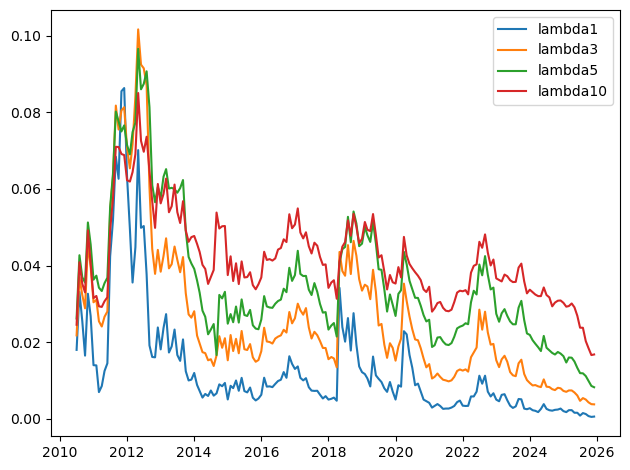

In [27]:

plt.figure()
plt.plot(out["Date"], out["lambda1"], label="lambda1")
plt.plot(out["Date"], out["lambda3"], label="lambda3")
plt.plot(out["Date"], out["lambda5"], label="lambda5")
plt.plot(out["Date"], out["lambda10"], label="lambda10")
plt.legend()
plt.tight_layout()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO462_HW8_Q1_Model_1.pdf")
plt.savefig(save_path)

print("Figure saved to", save_path)


### 1(g) Inversion check

In [28]:

crisis = out[(out["Date"].dt.year>=2011) & (out["Date"].dt.year<=2012)]
inv = crisis[crisis["lambda1"] > crisis["lambda5"]]

print("Months with lambda1 > lambda5 (2011–2012):")
print(inv[["Date","lambda1","lambda3","lambda5","lambda10"]])


Months with lambda1 > lambda5 (2011–2012):
         Date   lambda1   lambda3   lambda5  lambda10
16 2011-11-01  0.085527  0.080517  0.075020  0.069134
17 2011-12-01  0.086352  0.081347  0.076603  0.068851
